In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:

data = pd.read_csv("clothing_reviews_enriched.csv")


In [46]:

data.columns


Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'full_text', 'clean_text',
       'pred_relevance', 'pred_sentiment_score', 'pred_has_fit_info',
       'pred_has_size_info', 'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info'],
      dtype='object')

In [47]:
data

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,...,clean_text,pred_relevance,pred_sentiment_score,pred_has_fit_info,pred_has_size_info,pred_has_comfort_info,pred_has_material_info,pred_has_quality_info,pred_has_color_info,pred_has_type_info
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,...,absolutely wonderful silky and sexy and comfor...,0.999978,95.182920,3.598154e-05,2.977620e-07,9.999975e-01,6.307046e-05,0.000471,0.001875,0.008676
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,...,love this dress it's sooo pretty i happened to...,1.000000,98.030396,9.996808e-01,1.000000e+00,3.693655e-05,4.034051e-06,0.000002,0.000054,0.999995
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,...,some major design flaws i had such high hopes ...,1.000000,54.821026,9.999049e-01,9.999975e-01,9.997002e-01,1.643021e-03,0.999990,0.000004,0.999185
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,...,my favorite buy i love love love this jumpsuit...,0.012738,98.573210,2.842368e-08,7.393026e-09,9.207025e-04,2.019353e-06,0.000092,0.000041,0.000372
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,...,flattering shirt this shirt is very flattering...,1.000000,96.113740,9.999984e-01,2.548138e-06,2.280905e-04,4.197253e-05,0.000129,0.000005,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22637,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses,...,great dress for many occasions i was very happ...,1.000000,98.492560,9.999982e-01,1.613055e-04,3.166117e-02,8.725703e-06,0.000005,0.999977,0.999956
22638,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits,...,wish it was made of cotton it reminds me of ma...,1.000000,70.424736,9.999587e-01,2.227598e-02,9.990309e-01,9.999958e-01,0.118966,0.000029,0.000035
22639,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses,...,cute but see through this fit well but the top...,1.000000,54.053585,9.999955e-01,4.052383e-05,2.420251e-07,9.999991e-01,0.000107,0.000006,0.999995
22640,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses,...,very cute dress perfect for summer parties and...,1.000000,84.014470,9.999964e-01,9.999934e-01,9.379737e-08,2.434195e-06,0.000005,0.000014,0.999996


Проверим данные на пропуски:

In [48]:
data.isna().sum()

,0
Clothing ID,0
Age,0
Title,2966
Review Text,1
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,13
Department Name,13
Class Name,13


Тут все хорошо, пропуски есть только в заголовке, департаменте, классе, дивизионе и в одном отзыве, их заменять не надо, это может помочь модели сделать полезные выводы

Добавим колонки длины отзыва, длины заголовка и его наличия, так как это может в том числе влиять на качество и полезность отзыва для покупателя:

In [49]:

data["Has Title"] = (~data["Title"].isna()).astype(int)
data["Title Length"] = data["Title"].fillna("").str.split().str.len()
data["Review Length"] = data["Review Text"].fillna("").str.split().str.len()


Итак, мы предсказываем полезность отзыва, поэтому в качестве таргета рассмотрим признак Positive Feedback Count (кол-во пользователей, оценивших отзыв как полезный), рассмотрим распределений этого полказателя:

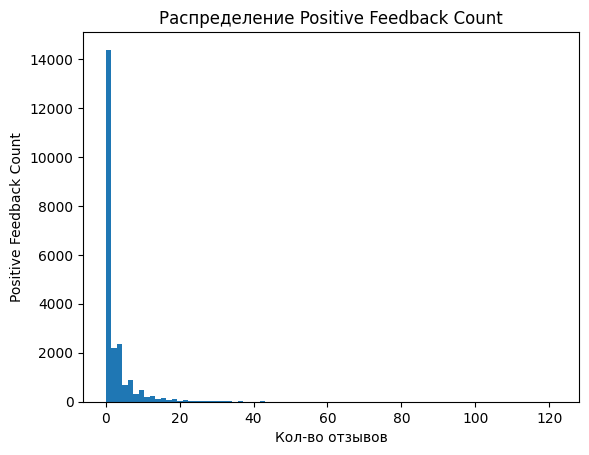

In [50]:

plt.hist(data["Positive Feedback Count"], bins=len(data["Positive Feedback Count"].unique()))
plt.title("Распределение Positive Feedback Count")
plt.xlabel("Кол-во отзывов")
plt.ylabel("Positive Feedback Count")
plt.show()

Заметим, что распределение сильно скошено вправо, поэтому рассмотрим возможность логарифмировать целевую переменную для снижения влияния выбросов

Также аметим, что в датасете преобладают отзывы без положительных отметок, важно понять, связано ли это с их низким качеством или низкой популярностью товаров. Популярность измерим как кол-во отзывов

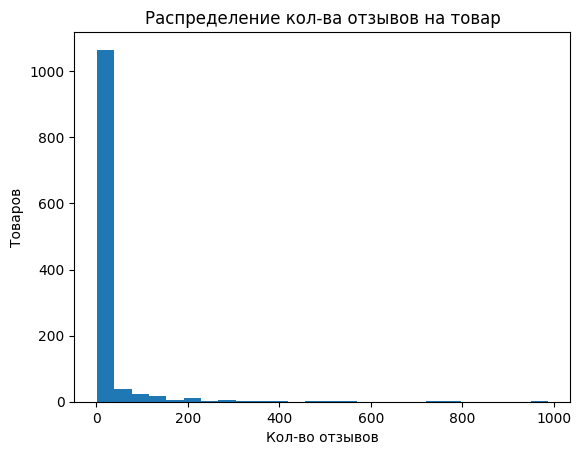

In [51]:

review_count = data.groupby(["Clothing ID"]).size()
review_count
plt.hist(review_count, bins=len(review_count.unique())//5)
plt.title("Распределение кол-ва отзывов на товар")
plt.xlabel("Кол-во отзывов")
plt.ylabel("Товаров")
plt.show()


В датаесте также преобладают малопопулярные товары, получается знаечение Positive Feedback Count для отзывов на популярные товары будет значительно выше, чтобы этого избежать будем предсказывать не просто логарифм от кол-ва людей, посчитавших отзыв полезным - log(1 + Positive Feedback Count), а отношение полезности рассматриваемого отзыва к средней полезности по товару - log( (1 + Positive Feedback Count) / (1 + Mean Positive Feedback Count) )

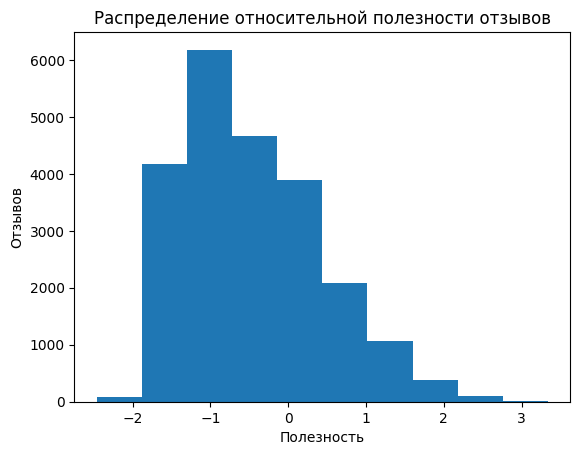

In [52]:

data["Mean Positive Feedback Count"] = data.groupby("Clothing ID")["Positive Feedback Count"].transform("mean")
data["log_usefulness"] = np.log((1 + data["Positive Feedback Count"]) / (1 + data["Mean Positive Feedback Count"]))
data["log_usefulness"]

plt.hist(data["log_usefulness"])
plt.title("Распределение относительной полезности отзывов")
plt.xlabel("Полезность")
plt.ylabel("Отзывов")
plt.show()



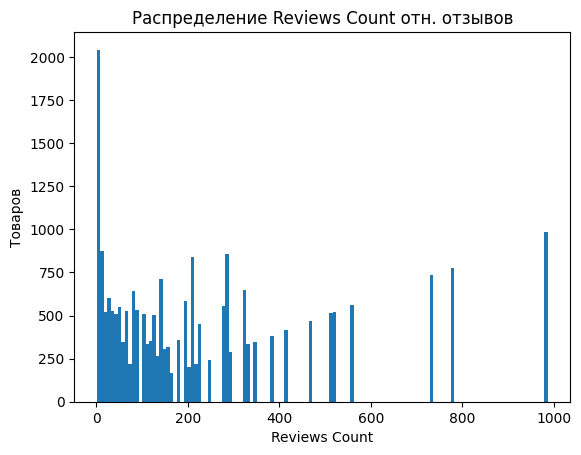

In [53]:

data["Reviews Count"] = data.groupby("Clothing ID")["Clothing ID"].transform("count")

plt.hist(data["Reviews Count"], bins=len(data["Reviews Count"].unique()))
plt.title("Распределение Reviews Count отн. отзывов")
plt.xlabel("Reviews Count")
plt.ylabel("Товаров")
plt.show()



По распределению количества товаров по кол-ву отзывов видим, что можно будет +- безболезнено для размера датасета удалить товары с малым кол-вом отзывов

Это нужно, так как хорошие отзывы могут иметь низкую оценку просто при низкой популярности товаров, что снизит качество модели

In [54]:

for threshold in range(10):
  print(f'Размер датасета при удалении товаров с {threshold} и меньше отзывов: {data[data["Reviews Count"] > threshold].shape[0]}')
  print(f'Удалено отзывов из датасета в процентах: {100 * (1 - data[data["Reviews Count"] > threshold].shape[0]/ data.shape[0])}')
  print()

Размер датасета при удалении товаров с 0 и меньше отзывов: 22642
Удалено отзывов из датасета в процентах: 0.0

Размер датасета при удалении товаров с 1 и меньше отзывов: 22168
Удалено отзывов из датасета в процентах: 2.093454641816095

Размер датасета при удалении товаров с 2 и меньше отзывов: 21778
Удалено отзывов из датасета в процентах: 3.8159173217913622

Размер датасета при удалении товаров с 3 и меньше отзывов: 21529
Удалено отзывов из датасета в процентах: 4.915643494390953

Размер датасета при удалении товаров с 4 и меньше отзывов: 21281
Удалено отзывов из датасета в процентах: 6.010953096016259

Размер датасета при удалении товаров с 5 и меньше отзывов: 21066
Удалено отзывов из датасета в процентах: 6.960515855489802

Размер датасета при удалении товаров с 6 и меньше отзывов: 20904
Удалено отзывов из датасета в процентах: 7.676000353325674

Размер датасета при удалении товаров с 7 и меньше отзывов: 20736
Удалено отзывов из датасета в процентах: 8.417984277007328

Размер датасе

Заметм, что если удалить из датасета все товары с <= 4 отзывами, то останется 94% изначальных записей, это несильно уменьшит датасет и позволит не обучаться на необъетивных данных из совсем непопулярных товаров. Можно было удалить и больше, но обучать модель только на популярных товарах тоже неправильно

In [55]:

data = data[data["Reviews Count"] > 4].reset_index(drop=True)
data


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,...,pred_has_material_info,pred_has_quality_info,pred_has_color_info,pred_has_type_info,Has Title,Title Length,Review Length,Mean Positive Feedback Count,log_usefulness,Reviews Count
0,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,...,4.034051e-06,0.000002,0.000054,0.999995,0,0,62,3.032143,0.215140,280
1,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,...,1.643021e-03,0.999990,0.000004,0.999185,1,4,98,2.445993,-1.237212,287
2,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,...,2.019353e-06,0.000092,0.000041,0.000372,1,3,22,2.903226,-1.361803,31
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,...,7.996169e-05,0.000230,0.999219,0.999925,1,5,98,3.032143,0.215140,280
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,...,1.394712e-05,0.000006,0.999936,0.999857,1,3,101,2.047619,-0.421213,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21276,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses,...,8.725703e-06,0.000005,0.999977,0.999956,1,5,28,3.261364,-1.449589,176
21277,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits,...,9.999958e-01,0.118966,0.000029,0.000035,1,6,38,2.493573,-1.250925,778
21278,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses,...,9.999991e-01,0.000107,0.000006,0.999995,1,4,42,3.261364,-0.756442,176
21279,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses,...,2.434195e-06,0.000005,0.000014,0.999996,1,9,86,2.430556,-0.134110,72


Теперь разберем категориальные признаки: 'Division Name', 'Department Name', 'Class Name'

In [56]:

data["Division Name"].unique()


array(['General', 'General Petite', 'Initmates'], dtype=object)

In [57]:

data["Department Name"].unique()


array(['Dresses', 'Bottoms', 'Tops', 'Jackets', 'Intimate', 'Trend'],
      dtype=object)

In [58]:

data["Class Name"].unique()


array(['Dresses', 'Pants', 'Knits', 'Blouses', 'Sweaters', 'Skirts',
       'Outerwear', 'Jackets', 'Fine gauge', 'Jeans', 'Lounge', 'Swim',
       'Legwear', 'Sleep', 'Trend', 'Intimates', 'Shorts', 'Layering'],
      dtype=object)



*   Division Name - самый крупный уровень деления товаро типам
*   Departament Name - более детальный
*   Class Name - еще более детальный



Мы уже видели, что по этим признакам всего 13 пропусков, поэтому просто удалим эти строки

Закодируем их через OHE, получится адекватное кол-во новых полей

In [59]:

data = data.dropna(subset = ['Division Name', 'Department Name', 'Class Name']).copy()
data = pd.get_dummies(data, columns=['Division Name', 'Department Name', 'Class Name'])
data.columns


Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'full_text', 'clean_text',
       'pred_relevance', 'pred_sentiment_score', 'pred_has_fit_info',
       'pred_has_size_info', 'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info',
       'Has Title', 'Title Length', 'Review Length',
       'Mean Positive Feedback Count', 'log_usefulness', 'Reviews Count',
       'Division Name_General', 'Division Name_General Petite',
       'Division Name_Initmates', 'Department Name_Bottoms',
       'Department Name_Dresses', 'Department Name_Intimate',
       'Department Name_Jackets', 'Department Name_Tops',
       'Department Name_Trend', 'Class Name_Blouses', 'Class Name_Dresses',
       'Class Name_Fine gauge', 'Class Name_Intimates', 'Class Name_Jackets',
       'Class Name_Jeans', 'Class Name_Knits', 'Class Name_Layering',
       'Class Name_Legwear', 'Clas

Теперь проанализиуем наши числовые признаки на выбросы:

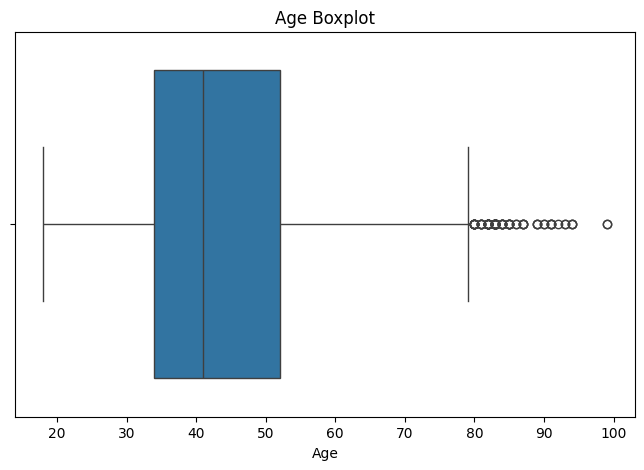

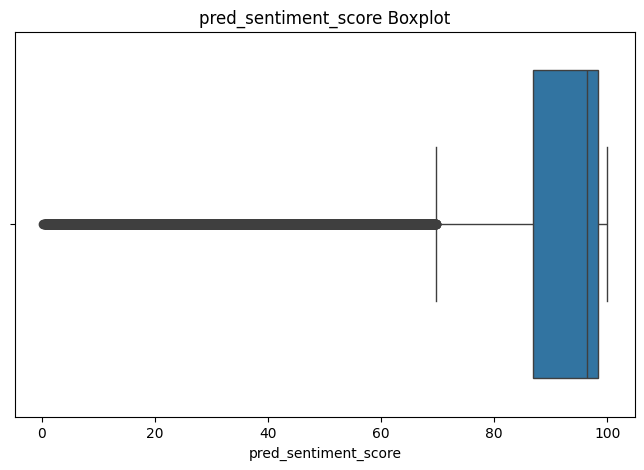

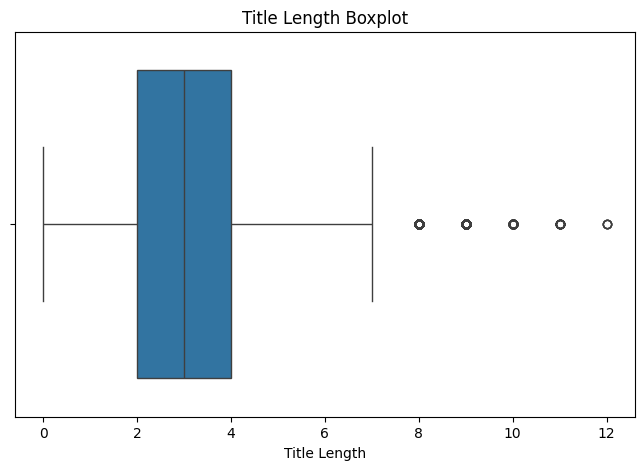

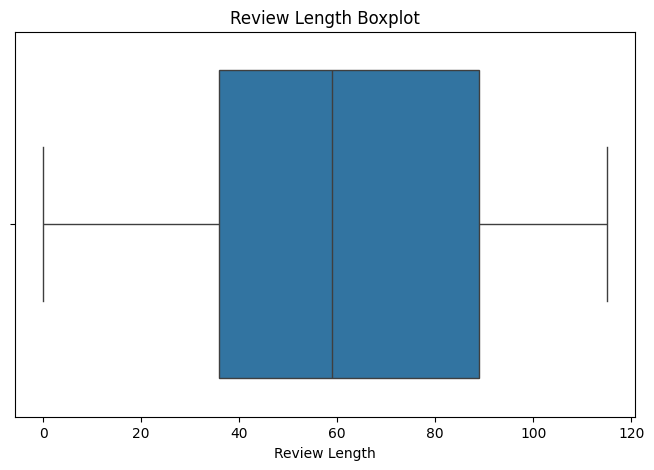

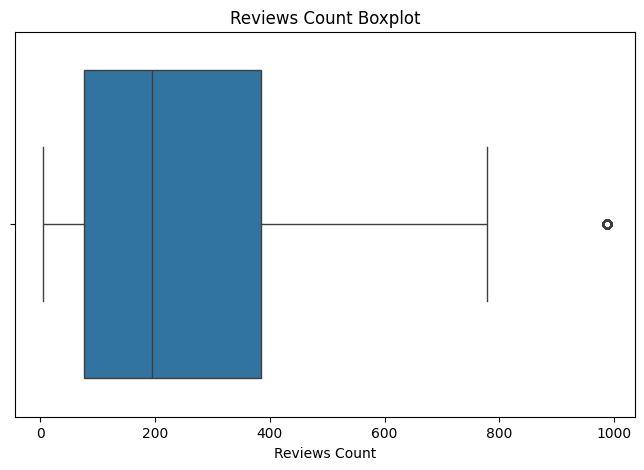

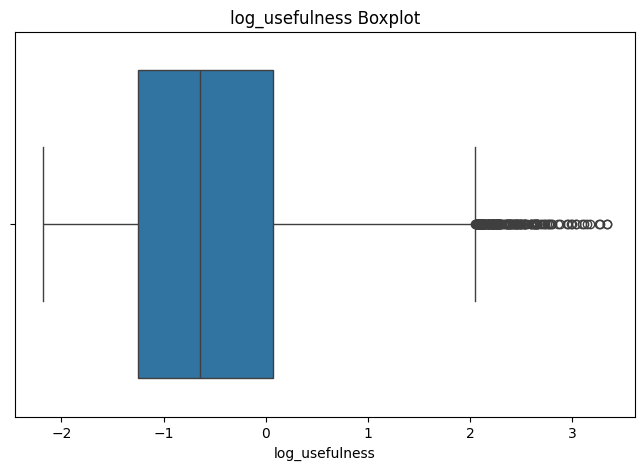

In [60]:


cols = ["Age", "pred_sentiment_score", "Title Length", "Review Length", "Reviews Count", "log_usefulness"]

for col in cols:
  plt.figure(figsize=(8, 5))
  sns.boxplot(data=data[col], orient="h")
  plt.title(f"{col} Boxplot")
  plt.show()





*   В целом возраст не более 100 лет, выбросов не много, ими просто являются пожилые люди, удалять не нужно, так как пожилые люди могут иметь отдельный стиль написания отзывов
*   Видим, что по эмоциональному окрасу большинство отзывов позитивные, тем неменее негативные отзывы не являются выбросами, они нужны для построения модели, так как негативные отзывы могут содержат обоснованную критику
*   По длине заголовка не видим аномальных значений, можно не удалять
*   По длине отзыва выбросов нет
*   По популярности (кол-ву отзывов) видим 1 выброс с ~1000 отзывов. В целом показатель популярности товара использовать как предиктор не планировалось и учитывая относительный характер таргетаа, такие отзывы можно не удалять
*   Для нашего таргета видим довольно много выбросов (отзывов с высокой относительной полезностью), но удалять их не нужно, так как модель как раз должна учиться нахожить такие отзывы


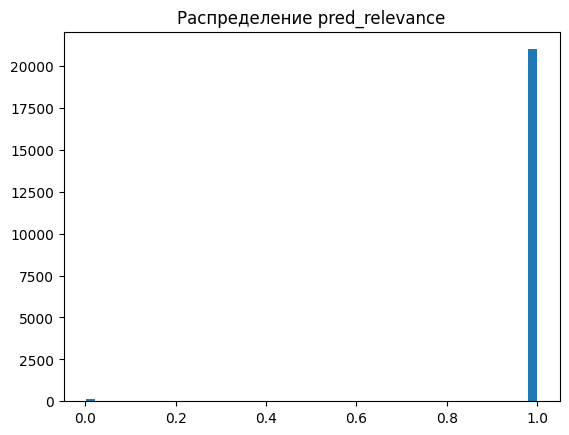

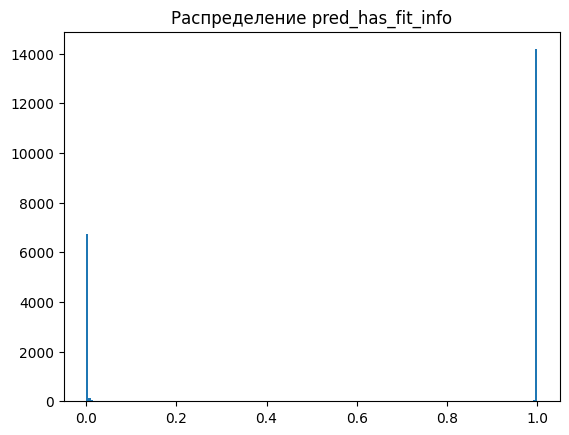

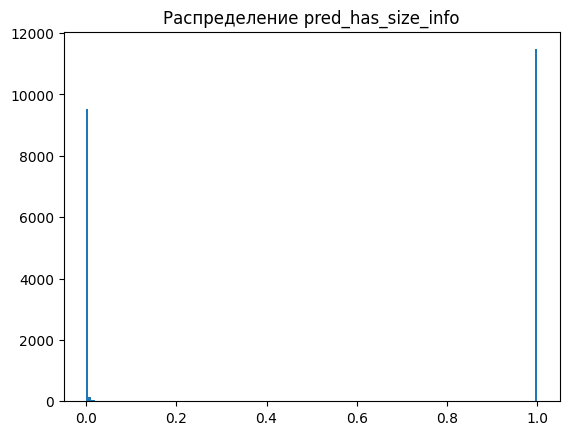

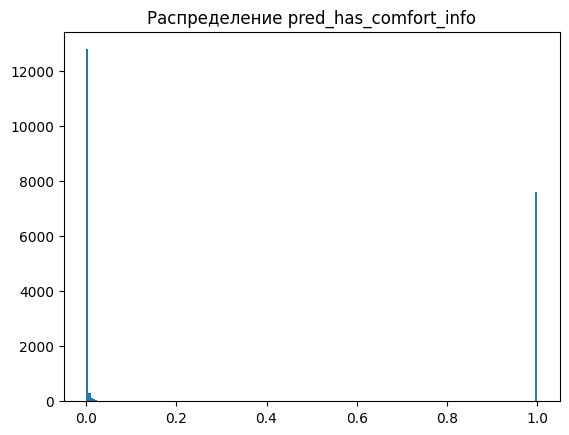

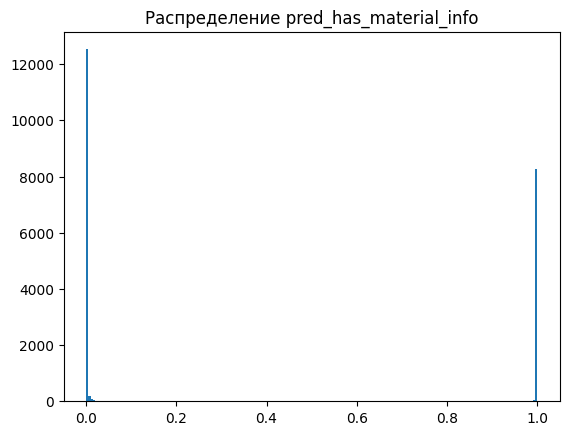

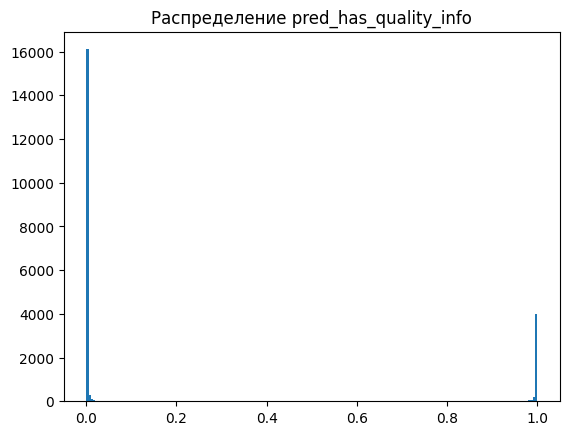

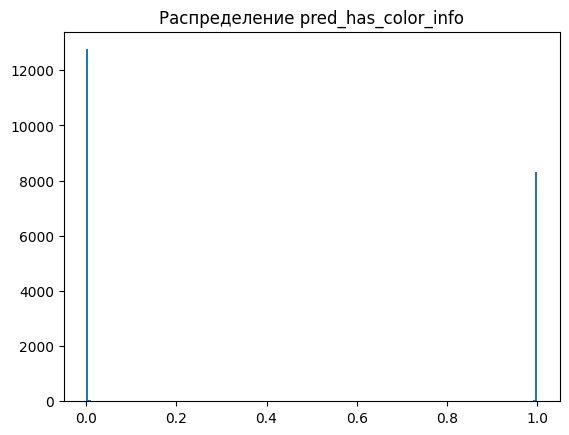

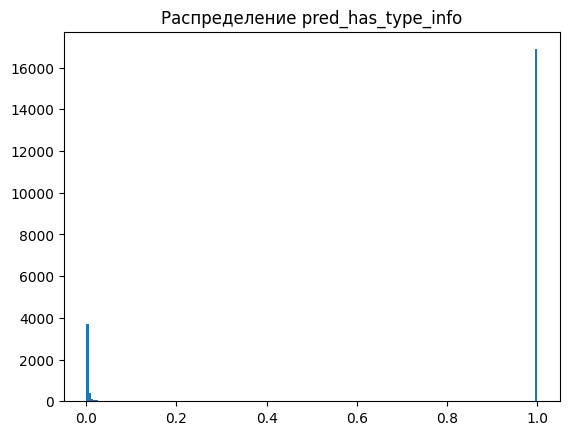

In [61]:

cols = ['pred_has_fit_info',
       'pred_has_size_info', 'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info']

plt.hist(data["pred_relevance"], bins=50)
plt.title("Распределение pred_relevance")
plt.show()

for col in cols:
  plt.hist(data[col], bins=200)
  plt.title(f"Распределение {col}")
  plt.show()


Тут видим, что наши признаки релевантности и пренадлежности являются практически бинарными, тем не менее оставим их в виде скоров, чтобы фиксировать ситуации, когда информация есть, но ее нельзя расценить как полную

И наконец проверим корреляцию для всех признаков, которые хотим использовать в предсказании:

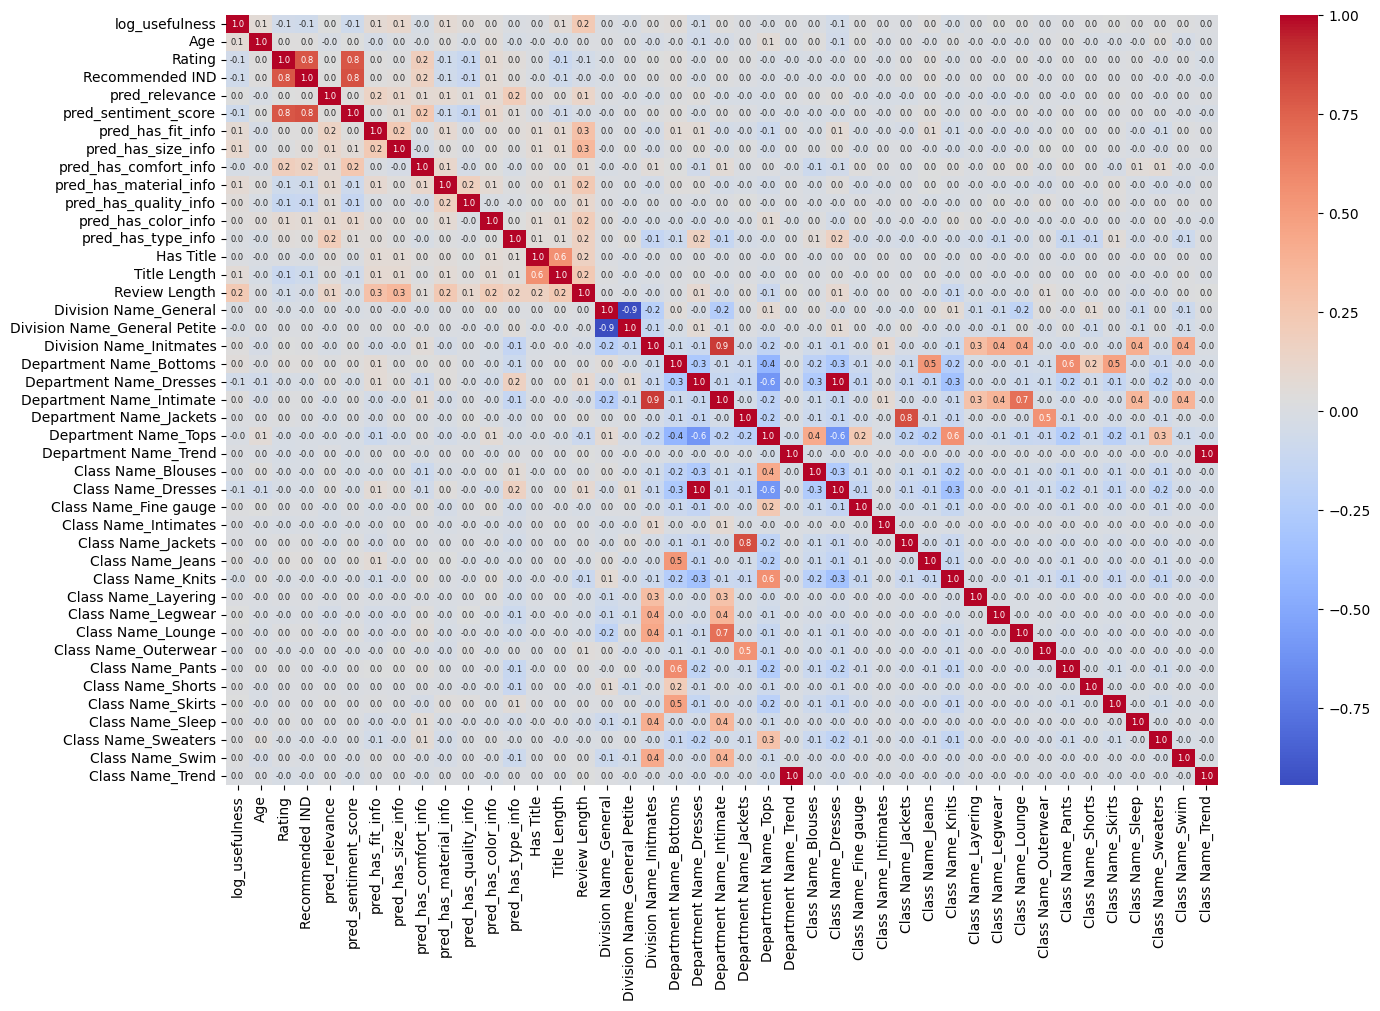

In [62]:

features = ['log_usefulness', 'Age', 'Rating', 'Recommended IND',
       'pred_relevance', 'pred_sentiment_score', 'pred_has_fit_info',
       'pred_has_size_info', 'pred_has_comfort_info', 'pred_has_material_info',
       'pred_has_quality_info', 'pred_has_color_info', 'pred_has_type_info',
       'Has Title', 'Title Length', 'Review Length',
       'Division Name_General', 'Division Name_General Petite',
       'Division Name_Initmates', 'Department Name_Bottoms',
       'Department Name_Dresses', 'Department Name_Intimate',
       'Department Name_Jackets', 'Department Name_Tops',
       'Department Name_Trend', 'Class Name_Blouses', 'Class Name_Dresses',
       'Class Name_Fine gauge', 'Class Name_Intimates', 'Class Name_Jackets',
       'Class Name_Jeans', 'Class Name_Knits', 'Class Name_Layering',
       'Class Name_Legwear', 'Class Name_Lounge', 'Class Name_Outerwear',
       'Class Name_Pants', 'Class Name_Shorts', 'Class Name_Skirts',
       'Class Name_Sleep', 'Class Name_Sweaters', 'Class Name_Swim',
       'Class Name_Trend']

correlation = data[features].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(correlation, cmap = 'coolwarm', annot=True, fmt=".1f", annot_kws={"size": 6})
plt.show()

Заметим, что наш таргет не имеет сильной линейной связи не с одним признаком, значит, отдельные признкаи слабо коррелируют с целевой переменной и задача требует модели, способной учитывать нелинейные закономерности

Ожидаемо, одну из самых сильных связей с целевой переменной имеет Review Length

Заметна сильная корреляция между флагом рекомендации и рейтингом, что также логично, можно будет попробовать обучить нейросеть включая и не включая один их этих признаков

Категориальные признаки сильно коррелируют друг с другом из-за иерархии, это нормально

Признаки наличия информации о материале качестве и т.д. слабо коррелируют с целевой переменной, однако могут лучше работать в сочетании с категорией

In [63]:
data[features + ["Positive Feedback Count", "Mean Positive Feedback Count", "Clothing ID"]].to_csv("prepared_reviews_data.csv", index=False)